# Statistics on graphs

In [1]:
import networkx
import torch, torch_geometric
import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

import pyvista as pv
import os

import karstnet as kn

# import json
import pickle

In [2]:
# Choose backend for matplotlib
# -----------------------------
from IPython import get_ipython
# get_ipython().run_line_magic('matplotlib', 'widget')
get_ipython().run_line_magic('matplotlib', 'inline')

# Or simply:
# %matplotlib widget
# %matplotlib inline

In [3]:
# Choose backend for pyvista with jupyter
# ---------------------------------------
# pv.set_jupyter_backend('trame')  # 3D-interactive plots
pv.set_jupyter_backend('static') # static plots

# Notes:
# -> ignored if run in a standard python shell
# -> use keyword argument "notebook=False" in Plotter() to open figure in a pop-up window

## Load local functions 

In [4]:
print('Load local functions...')

# import sys
# sys.path.insert(1, '../utils/')

# from graph_utils import *
# # from graph_rnn import *
# from graph_ddpm import *
# # from ml_utils import *
# from general_utils import *
# from graph_plot import *
# # from magic_utils import *
 
with open('../utils/graph_utils.py') as f: exec(f.read())
# with open('../utils/graph_rnn.py') as f: exec(f.read())
with open('../utils/graph_ddpm.py') as f: exec(f.read())
# with open('../utils/ml_utils.py') as f: exec(f.read())
with open('../utils/general_utils.py') as f: exec(f.read())
with open('../utils/graph_plot.py') as f: exec(f.read())
# with open('../utils/magic_utils.py') as f: exec(f.read())

Load local functions...


<string>:826: SyntaxWarning: invalid escape sequence '\m'
<string>:854: SyntaxWarning: invalid escape sequence '\m'
<string>:92: SyntaxWarning: invalid escape sequence '\s'


## Load parameters

Some parameters (dimension / attribute considered and indexes / parameters for plotting graphs)


In [5]:
print('Load parameters...')

# from params import *

with open('params.py') as f: exec(f.read())

Load parameters...


## Output settings

In [6]:
print('Define output settings...')

# Output directory (for saving)
# -----------------------------
fig_dir = 'fig'      # PARAMS

plt_show = True      # PARAMS (show graphics 2D ?)
off_screen = False   # PARAMS (show graphics 3D ?)

save_fig_png = True  # PARAMS
fig_prefix = '07'    # PARAMS

fig_counter = 0

if not os.path.isdir(fig_dir):
    os.mkdir(fig_dir)


Define output settings...


## Load graphs

### Load graphs from data set

In [7]:
print('Load graphs from data set...')

# Load from pickle file
data_dir = 'data_gen'
filename_graph_collection_data_set = os.path.join(data_dir, f'graph_collection_data_set.pickle')

with open(filename_graph_collection_data_set, 'rb') as f: data_set_G_list = pickle.load(f)

Load graphs from data set...


### Load list of generated graphs

In [8]:
print('Load generated graphs...')

in_dir_gen = 'out_gen_graph' 
filename_gen_graph_pk = os.path.join(in_dir_gen, f'gen_graph_list.pickle')

# Load list of generated graph (G_gen_list: of generated graphs in networkx format)
with open(filename_gen_graph_pk, 'rb') as f: G_gen_list = pickle.load(f)


Load generated graphs...


FileNotFoundError: [Errno 2] No such file or directory: 'out_gen_graph\\gen_graph_list.pickle'

## Show first graphs

### Graphs of data set

Plot first graphs of data set (2D)...


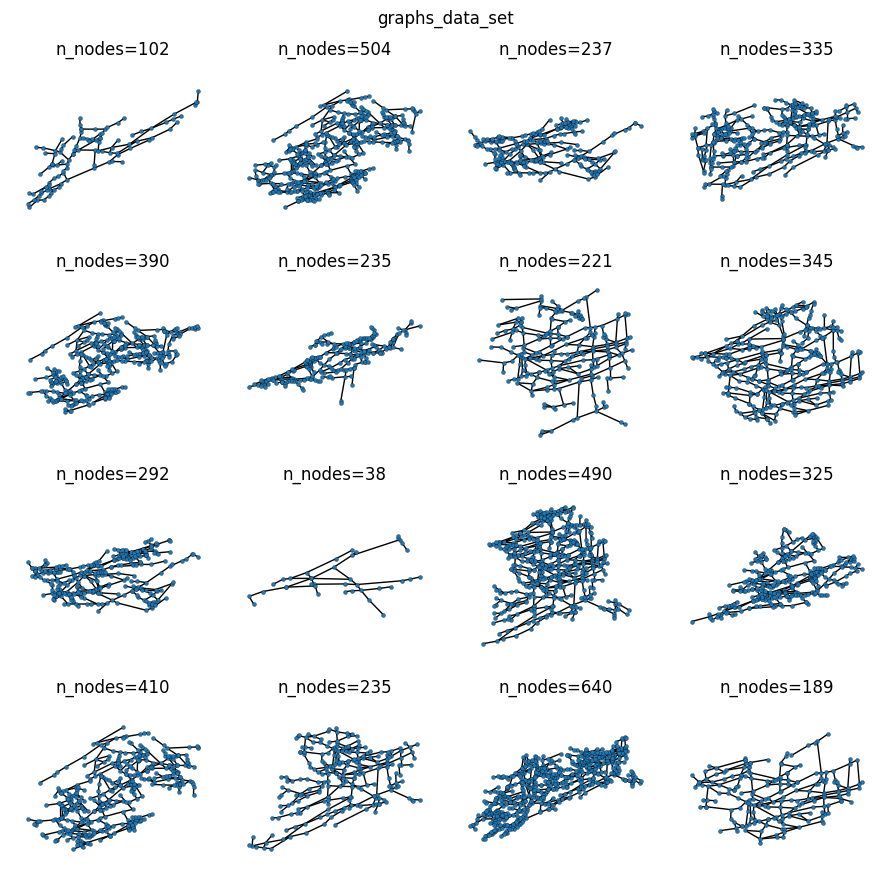

In [15]:
print('Plot first graphs of data set (2D)...')

G_list = data_set_G_list[:16]
out_name = 'graphs_data_set'

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

plot_graph_multi_2d_from_G_networkx_list(
        G_list, 
        out_name=out_name, 
        nr=None,
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title_list=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
        show=plt_show,
        **kwds)

### Generated graphs (graphRNN + ddpm)

Plot first generated graphs (2D)...


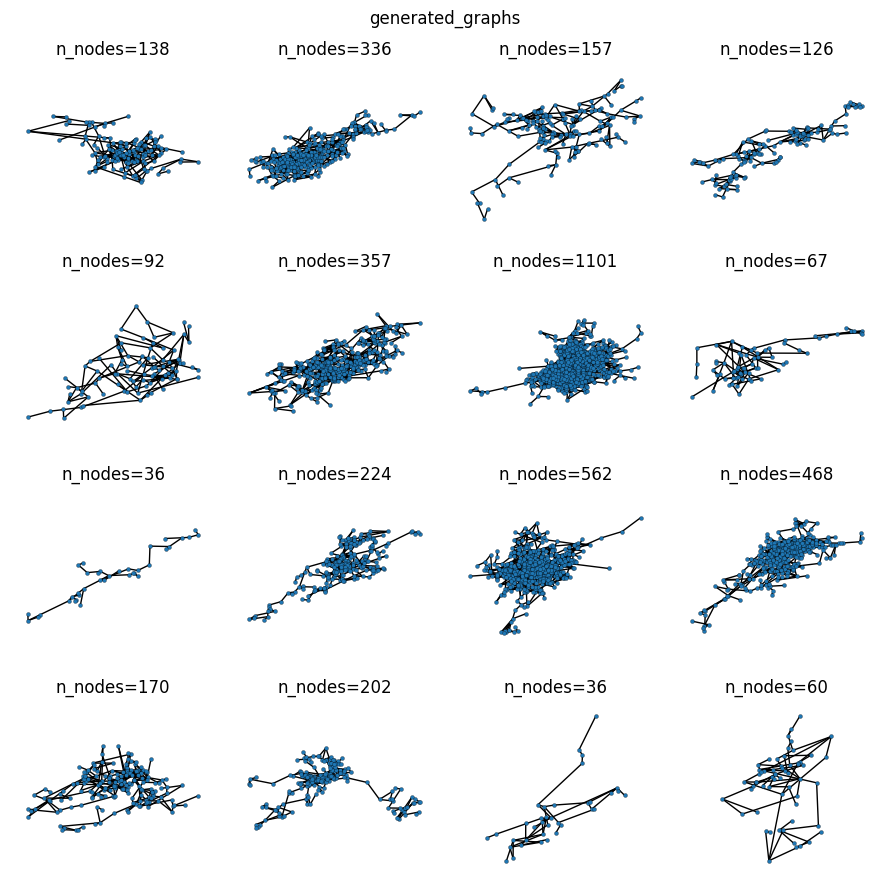

In [18]:
print('Plot first generated graphs (2D)...')

G_list = G_gen_list[:16]
out_name = 'generated_graphs'

# 2D view
# =======
kwds = kwds_multi.copy()

figsize = figsize_multi
# -----

same_color_bar = False

plot_graph_multi_2d_from_G_networkx_list(
        G_list, 
        out_name=out_name, 
        nr=None,
        attr=attr,
        attr_label_list=attr_label_list, 
        attr_cmap_list=attr_cmap_list,
        title_list=None, title_fontsize=12,
        figsize=figsize, save_fig_png=save_fig_png, 
        filename_prefix=f'{fig_dir}/{fig_prefix}_{fig_counter:02d}',
        with_labels=False, same_color_bar=same_color_bar, show_color_bar=True,
        show=plt_show,
        **kwds)

## Statistics

In [21]:
# Colors for further graphs
col_gen = 'tab:blue'
col_data = 'tab:orange'

col2_gen = 'darkblue'
col2_data = 'tab:red'


### Number of nodes

Compute and plot statistics - number of nodes...


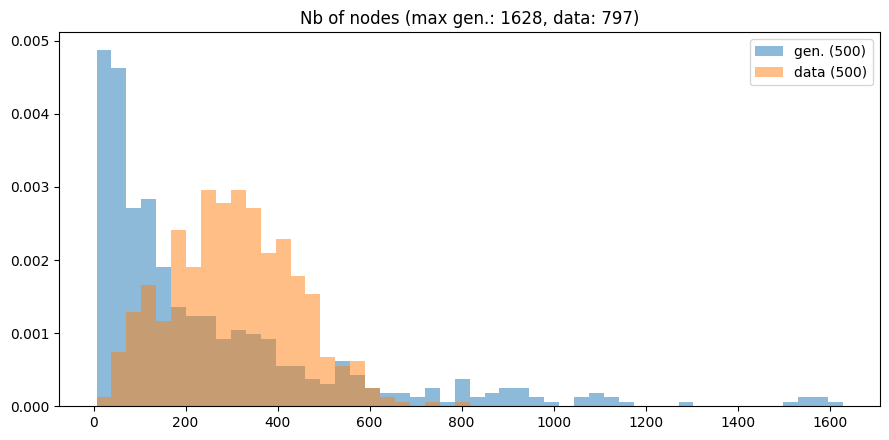

In [22]:
print('Compute and plot statistics - number of nodes...')

figsize = figsize_lh3

# Histogram of number of nodes
data_n_nodes = np.asarray([G.number_of_nodes() for G in data_set_G_list])
gen_n_nodes  = np.asarray([G.number_of_nodes() for G in G_gen_list])

# Plot
vmin = min(data_n_nodes.min(), gen_n_nodes.min()) - 0.5
vmax = max(data_n_nodes.max(), gen_n_nodes.max()) + 0.5
nb = min(int(vmax - vmin), 50)
bins = np.linspace(vmin, vmax, nb+1)

plt.figure(figsize=figsize)
plt.hist(gen_n_nodes,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen. ({len(gen_n_nodes)})')
plt.hist(data_n_nodes, density=True, bins=bins, color=col_data, alpha=.5, label=f'data ({len(data_n_nodes)})')
plt.legend()
plt.title(f'Nb of nodes (max gen.: {gen_n_nodes.max()}, data: {data_n_nodes.max()})')
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_nb_nodes.png')
    fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

Plot histogram of node features...


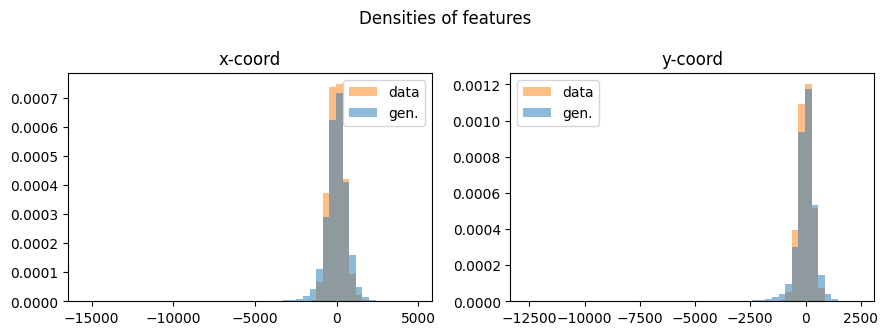

In [23]:
print('Plot histogram of node features...')

# Histogram of each node feature (coordinates of postion and attributes)
# ======================================================================
if dim==2:
    leg = ['x-coord', 'y-coord']
    col = ['tab:blue', 'tab:orange']
else:
    leg = ['x-coord', 'y-coord', 'z-coord']
    col = ['tab:blue', 'tab:orange', 'tab:purple']

if attr is not None:
    leg = leg + attr_label_list
    col = col + attr_ncomp*['tab:green']

ng = len(leg)
nr = int(np.sqrt(ng))
nc = ng//nr + (ng%nr>0)

figsize = (figsize_lh3[0], figsize_lh3[1]*nr*.75)

data_x_features = np.vstack([list(networkx.get_node_attributes(G, 'pos').values()) for G in data_set_G_list])
if attr is not None:
    v = np.vstack([list(networkx.get_node_attributes(G, attr).values()) for G in data_set_G_list])
    data_x_features = np.hstack((data_x_features, v))

gen_x_features = np.vstack([list(networkx.get_node_attributes(G, 'pos').values()) for G in G_gen_list])
if attr is not None:
    v = np.vstack([list(networkx.get_node_attributes(G, attr).values()) for G in G_gen_list])
    gen_x_features = np.hstack((gen_x_features, v))

x_features_min = np.vstack((data_x_features.min(axis=0), gen_x_features.min(axis=0))).min(axis=0)
x_features_max = np.vstack((data_x_features.max(axis=0), gen_x_features.max(axis=0))).max(axis=0)
x_features_nb = len(leg)*[50]
x_features_bins = [np.linspace(a, b, nb+1) for a, b, nb in zip(x_features_min, x_features_max, x_features_nb)]

# Plot
# ----
plt.subplots(nr, nc, figsize=figsize)
for i, label in enumerate(leg):
    plt.subplot(nr, nc, i+1)
    plt.hist(data_x_features[:, i], density=True, bins=x_features_bins[i], color=col_data, alpha=.5, label=f'data')
    plt.hist(gen_x_features[:, i],  density=True, bins=x_features_bins[i], color=col_gen,  alpha=.5, label=f'gen.')
    plt.title(f'{label}')
    plt.legend()

for i in range(ng, nr*nc):
    plt.subplot(nr, nc, i+1)
    plt.axis('off')

plt.suptitle(f'Densities of features')

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_node_features.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

## Statistics on nodes
Compute some statistics on nodes of every graph in data set and in generated list (and set results as node attributes).
The statistics measures computed are: *degree, degree_centrality, closeness_centrality, betweenness_centrality* (all normalized, i.e. the maximum is $1$).

Below, $n$ denotes the number of nodes in the graph, $u$, $v$ are nodes of the graph, $d(v)$ is the degree of $v$, and $d(u,v)$ is the length of the shortest path between node $u$ and $v$ (in number of edges).

- $degree\_centrality(v) = d(v)/(n-1)$ 
- $closeness\_centrality(v) = (n-1)/\sum_{u\neq v}d(u, v)$ 
- $betweenness\_centrality(v) = \frac{2}{(n-1)(n-2)}\sum_{\{s, t\} : s \neq t, s\neq v\neq t} \frac{\vert\{shortest\ path\ btw\ s\ and\ t\ going\ through\ v\}\vert}{\vert\{shortest\ path\ btw\ s\ and\ t\}\vert}$

<!-- ### Degree centrality
$degree\_centrality(v) = d(v)/(n-1),$
 
### Closeness centrality (for connected graph)
$closeness\_centrality(v) = (n-1)/\sum_{u\neq v}d(u, v)$

### Betweenness_centrality (for connected graph)
$betweenness\_centrality(v) = \frac{2}{(n-1)(n-2)}\sum_{\{s, t\} : s \neq t, s\neq v\neq t} \frac{\vert\{shortest\ path\ btw\ s\ and\ t\ going\ through\ v\}\vert}{\vert\{shortest\ path\ btw\ s\ and\ t\}\vert}$ -->


### Computation
Comments and loads the files if already existing (see next section).

In [27]:
print('Compute statistics on graph nodes (topology)...')

Compute statistics on graph nodes (topology)...


In [ ]:
import math
# Calculate lengths from graph edges
def lengths(graph):
    pos = nx.get_node_attributes(graph, 'pos')

    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)
        graph[u][v]['length'] = round(length, 3)

In [ ]:
def normalize_graph_lengths(G, method='mean'):
    lengths = nx.get_edge_attributes(G, 'length')
    if not lengths:
        return G # skip if no lengths

    # Save original lengths
    nx.set_node_attributes(G, lengths, 'original_length')

    # Choose norm factor
    if method == 'max':
        norm_factor = max(lengths.values())
    elif method == 'area':
        pos = nx.get_node_attributes(G, 'pos')
        xs = [p[0] for p in pos.values()]
        ys = [p[1] for p in pos.values()]
        area = (max(xs) - min(xs)) * (max(ys) - min(ys))
        norm_factor = np.sqrt(area) if area > 0 else 1.0
    else: # default is 'mean'
        norm_factor = np.mean(list(lengths.values()))

    # Avoid division by zero
    norm_factor = norm_factor if norm_factor > 0 else 1.0

    # Apply normalization
    normalized = {edge: l / norm_factor for edge, l in lengths.items()}
    nx.set_edge_attributes(G, normalized, 'length')

    # Store factor for possible reversal
    G.graph['length_norm_factor'] = norm_factor
    G.graph['length_norm_method'] = method

    return G

In [ ]:
# Calculate azimuths from graph edges
def azimuths(graph):
    pos = nx.get_node_attributes(graph, 'pos')
    for u, v in graph.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        
        # Calculate the angle between the edge and the positive y-axis
        angle_radians = math.atan2(x2 - x1, y2 - y1)
        graph[u][v]['rad'] = round(angle_radians, 2)
        
        angle_degrees = math.degrees(angle_radians)
        azimuth = (angle_degrees + 360) % 360
        graph[u][v]['azimuth'] = round(azimuth, 2) 

In [28]:
# Graphs in data set
t1 = time.time()
for G in data_set_G_list:
    networkx.set_node_attributes(G, dict(networkx.degree(G)), 'degree')
    networkx.set_node_attributes(G, networkx.closeness_centrality(G), 'closeness_centrality')
    networkx.set_node_attributes(G, networkx.betweenness_centrality(G), 'betweenness_centrality')
    networkx.set_node_attributes(G, networkx.estrada_index(G), 'estrada_index')
    networkx.set_node_attributes(G, networkx.average_clustering(G), 'av_clustering')
    networkx.set_node_attributes(G, networkx.global_efficiency(G), 'global_efficiency')
    networkx.set_node_attributes(G, lengths(G), 'lengths')
    networkx.set_node_attributes(G, azimuths(G), 'azimuths')
        
t2 = time.time()
print(f'Elapsed time for computing statistics on nodes ({len(data_set_G_list)} graph(s)): {t2-t1:.3g} s')

Elapsed time for computing statistics on nodes (500 graph(s)): 144 s


In [29]:
# Generated graphs
t1 = time.time()
for G in G_gen_list:
    networkx.set_node_attributes(G, dict(networkx.degree(G)), 'degree')
    networkx.set_node_attributes(G, networkx.closeness_centrality(G), 'closeness_centrality')
    networkx.set_node_attributes(G, networkx.betweenness_centrality(G), 'betweenness_centrality')
    networkx.set_node_attributes(G, networkx.estrada_index(G), 'estrada_index')
    networkx.set_node_attributes(G, networkx.average_clustering(G), 'av_clustering')
    networkx.set_node_attributes(G, networkx.global_efficiency(G), 'global_efficiency')
    networkx.set_node_attributes(G, lengths(G), 'lengths')
    networkx.set_node_attributes(G, azimuths(G), 'azimuths')
    
t2 = time.time()
print(f'Elapsed time for computing statistics on nodes ({len(G_gen_list)} graph(s)): {t2-t1:.3g} s')

Elapsed time for computing statistics on nodes (500 graph(s)): 155 s


### Save to / Load from file (pickle)
Comments appropriate lines.

In [30]:
# Graphs in data set with stats on nodes
filename_data_set_graph_stats_pk = os.path.join(in_dir_gen, f'data_set_graph_list_with_stats_on_nodes.pickle')

# Save pickle
print('Save data set with statistics on nodes (topology)...')
with open(filename_data_set_graph_stats_pk, 'wb') as f: pickle.dump(data_set_G_list, file=f)

# # Load pickle
# print('Load data set with statistics on nodes (topology)...')
# with open(filename_data_set_graph_stats_pk, 'rb') as f: data_set_G_list = pickle.load(f)

Save data set with statistics on nodes (topology)...


In [31]:
# Generated graphs with stats on nodes
filename_gen_graph_stats_pk = os.path.join(in_dir_gen, f'gen_graph_list_with_stats_on_nodes.pickle')

# Save pickle
print('Save generated graphs with statistics on nodes (topology)...')
with open(filename_gen_graph_stats_pk, 'wb') as f: pickle.dump(G_gen_list, file=f)

# # Load pickle
# print('Load generated graphs with statistics on nodes (topology)...')
# with open(filename_gen_graph_stats_pk, 'rb') as f: G_gen_list = pickle.load(f)

Save generated graphs with statistics on nodes (topology)...


### Plots

In [33]:
figsize = figsize_lh4

### Degree

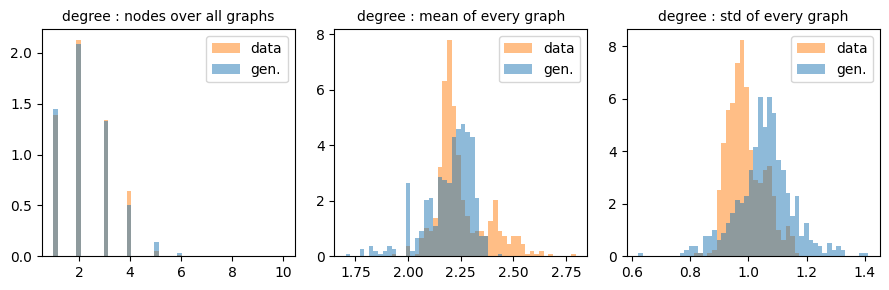

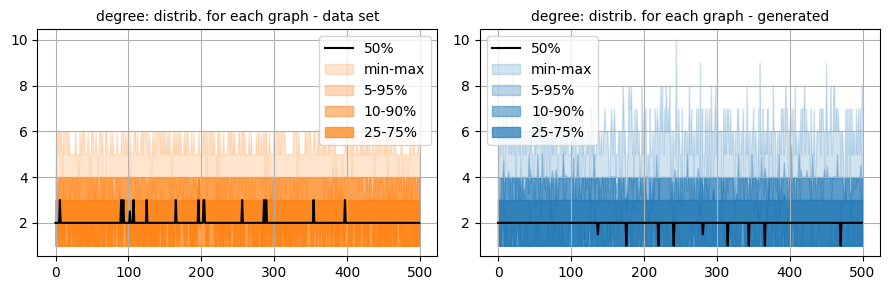

In [34]:
# Attribute (key)
attr_stat = 'degree'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean of every graph', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std of every graph', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Closeness centrality

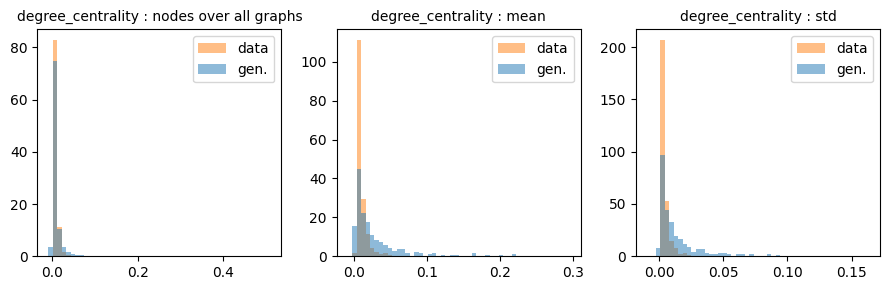

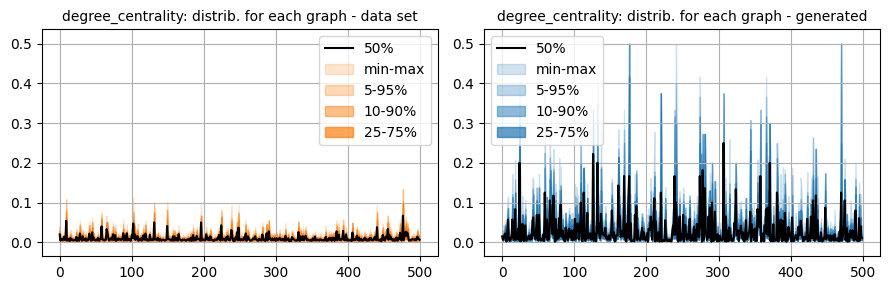

In [35]:
# Attribute (key)
attr_stat = 'closeness_centrality'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Beetweeness centrality

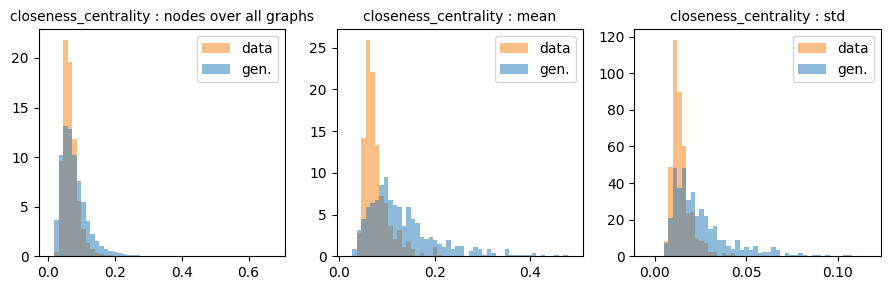

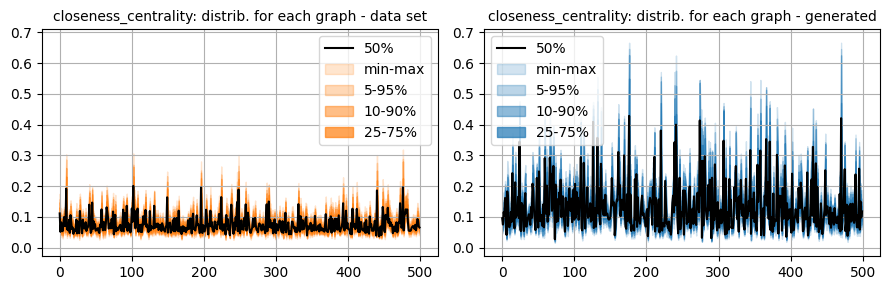

In [36]:
# Attribute (key)
attr_stat = 'betweenness_centrality'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])


# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Estrada Index

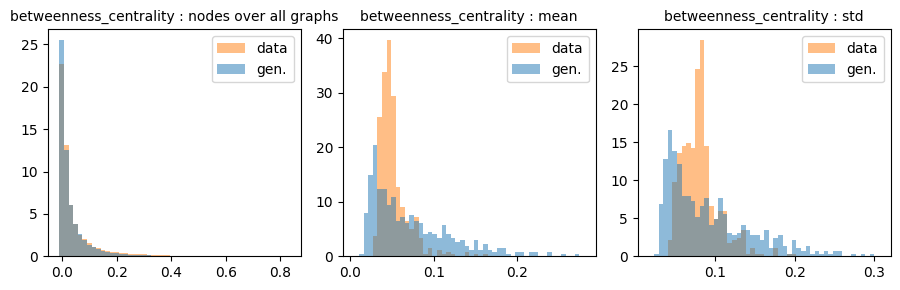

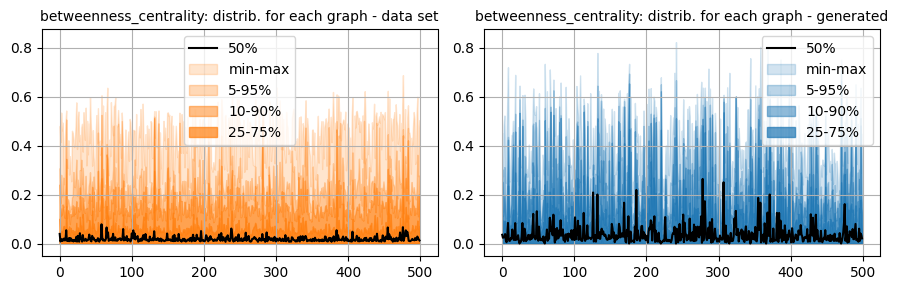

In [37]:
# Attribute (key)
attr_stat = 'estrada_index'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

In [ ]:
# Attribute (key)
attr_stat = 'av_clustering'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])


# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

In [ ]:
# Attribute (key)
attr_stat = 'global_efficiency'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

In [ ]:
# Attribute (key)
attr_stat = 'lengths'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])


# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

In [ ]:
# Attribute (key)
attr_stat = 'azimuths'

# Set distribution
# ----------------
# distribution of each graph
data_distrib = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in data_set_G_list]
gen_distrib  = [np.array(list(networkx.get_node_attributes(G, attr_stat).values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all = np.hstack(data_distrib)
gen_distrib_all  = np.hstack(gen_distrib)

# distribution of mean for each graph
data_distrib_mean = np.asarray([d.mean() for d in data_distrib])
gen_distrib_mean  = np.asarray([d.mean() for d in gen_distrib])

# distribution of standard deviation for each graph
data_distrib_std = np.asarray([d.std() for d in data_distrib])
gen_distrib_std  = np.asarray([d.std() for d in gen_distrib])

# Plot
# ----
plt.subplots(1,3, figsize=figsize)

plt.subplot(1,3,1)
vmin = min(data_distrib_all.min(), gen_distrib_all.min()) - 0.01
vmax = max(data_distrib_all.max(), gen_distrib_all.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_all, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_all,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : nodes over all graphs', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,2)
vmin = min(data_distrib_mean.min(), gen_distrib_mean.min()) - 0.01
vmax = max(data_distrib_mean.max(), gen_distrib_mean.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_mean, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_mean,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : mean', fontsize=10)
plt.legend()
#plt.grid()

plt.subplot(1,3,3)
vmin = min(data_distrib_std.min(), gen_distrib_std.min()) - 0.01
vmax = max(data_distrib_std.max(), gen_distrib_std.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_std, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_std,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'{attr_stat} : std', fontsize=10)
plt.legend()
#plt.grid()

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_{attr_stat}_1.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

### Graphics - histograms

In [ ]:
# Set distribution - Degree
# ----------------
# distribution of each graph
data_distrib_d = [np.array(list(networkx.get_node_attributes(G, 'degree').values())) for G in data_set_G_list]
gen_distrib_d  = [np.array(list(networkx.get_node_attributes(G, 'degree').values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all_d = np.hstack(data_distrib_d)
gen_distrib_all_d  = np.hstack(gen_distrib_d)

# distribution of mean for each graph
data_distrib_mean_d = np.asarray([d.mean() for d in data_distrib_d])
gen_distrib_mean_d  = np.asarray([d.mean() for d in gen_distrib_d])

# distribution of standard deviation for each graph
data_distrib_std_d = np.asarray([d.std() for d in data_distrib_d])
gen_distrib_std_d  = np.asarray([d.std() for d in gen_distrib_d])

In [ ]:
# Set distribution - Betweenness Centrality
# ----------------
# distribution of each graph
data_distrib_b = [np.array(list(networkx.get_node_attributes(G, 'betweenness_centrality').values())) for G in data_set_G_list]
gen_distrib_b  = [np.array(list(networkx.get_node_attributes(G, 'betweenness_centrality').values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

# distribution of all graphs together
data_distrib_all_b = np.hstack(data_distrib_b)
gen_distrib_all_b  = np.hstack(gen_distrib_b)

# distribution of mean for each graph
data_distrib_mean_b = np.asarray([d.mean() for d in data_distrib_b])
gen_distrib_mean_b  = np.asarray([d.mean() for d in gen_distrib_b])

# distribution of standard deviation for each graph
data_distrib_std_b = np.asarray([d.std() for d in data_distrib_b])
gen_distrib_std_b  = np.asarray([d.std() for d in gen_distrib_b])

In [ ]:
# Set distribution - Normalized Length
# ----------------
# distribution of each graph
data_distrib_l0 = [np.array(list(networkx.get_node_attributes(G, 'length').values())) for G in data_set_G_list]
gen_distrib_l0  = [np.array(list(networkx.get_node_attributes(G, 'length').values())) for G in G_gen_list]
# Note: each entry in the lists above is an array of values of length equal to the number of nodes in the corresponding graph

data_distrib_l = normalize_graph_lengths(data_distrib_10, method='max')
gen_distrib_l = normalize_graph_lengths(gen_distrib_10, method='max')

# distribution of all graphs together
data_distrib_all_l = np.hstack(data_distrib_l)
gen_distrib_all_l  = np.hstack(gen_distrib_l)

# distribution of mean for each graph
data_distrib_mean_l = np.asarray([d.mean() for d in data_distrib_l])
gen_distrib_mean_l  = np.asarray([d.mean() for d in gen_distrib_l])

# distribution of standard deviation for each graph
data_distrib_std_l = np.asarray([d.std() for d in data_distrib_l])
gen_distrib_std_l  = np.asarray([d.std() for d in gen_distrib_l])

In [ ]:
# Set distribution - Azimuths
# ----------------
# distribution of each graph
data_distrib_a = [np.array(list(networkx.get_node_attributes(G, 'azimuth').values())) for G in data_set_G_list]
gen_distrib_a  = [np.array(list(networkx.get_node_attributes(G, 'azimuth').values())) for G in G_gen_list]

data_distrib_r = np.deg2rad(data_distrib_a)
gen_distrib_r = np.deg2rad(gen_distrib_a)

# distribution of all graphs together
data_distrib_all_r = np.hstack(data_distrib_r)
gen_distrib_all_r  = np.hstack(gen_distrib_r)

# distribution of mean for each graph
data_distrib_mean_r = np.asarray([d.np.circmean() for d in data_distrib_r])
gen_distrib_mean_r  = np.asarray([d.np.circmean() for d in gen_distrib_r])

# distribution of standard deviation for each graph
data_distrib_std_r = np.asarray([d.np.circstd() for d in data_distrib_r])
gen_distrib_std_r  = np.asarray([d.np.circstd() for d in gen_distrib_r])

Plot Karstnet statistics (histogram)...


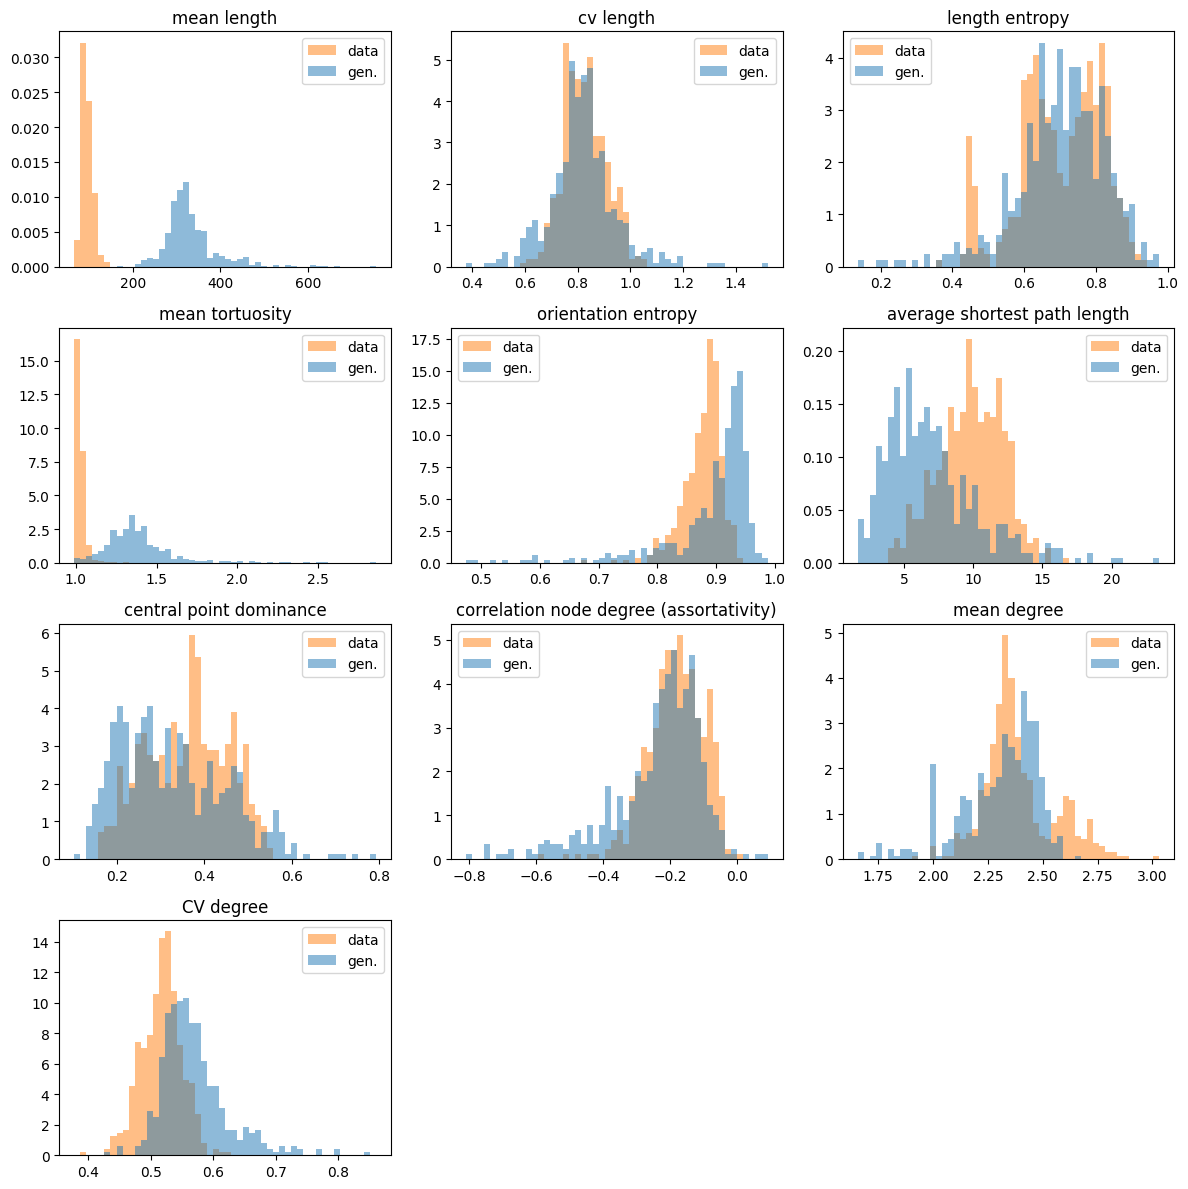

In [42]:
print('Plot Fracture network statistics (histogram)...')

# Plot
# ----
figsize = figsize_equal_l6

plt.subplots(4,3, figsize=figsize)

plt.subplot(4,3,1)
vmin = min(data_distrib_d.min(), gen_distrib_d.min()) - 0.01
vmax = max(data_distrib_d.max(), gen_distrib_d.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_d, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_d,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'mean degree')
plt.legend()
#plt.grid()

plt.subplot(4,3,2)
vmin = min(data_distrib_b.min(), gen_distrib_b.min()) - 0.01
vmax = max(data_distrib_b.max(), gen_distrib_b.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_b, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_b,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'betweenness centrality')
plt.legend()
#plt.grid()

plt.subplot(4,3,3)
vmin = min(data_distrib_l.min(), gen_distrib_l.min()) - 0.01
vmax = max(data_distrib_l.max(), gen_distrib_l.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_l, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_l,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'mean length')
plt.legend()
#plt.grid()

plt.subplot(4,3,4)
vmin = min(data_distrib_r.min(), gen_distrib_r.min()) - 0.01
vmax = max(data_distrib_r.max(), gen_distrib_r.max()) + 0.01
nb = 50
bins = np.linspace(vmin, vmax, nb+1)
plt.hist(data_distrib_r, density=True, bins=bins, color=col_data, alpha=.5, label=f'data')
plt.hist(gen_distrib_r,  density=True, bins=bins, color=col_gen,  alpha=.5, label=f'gen.')
plt.title(f'mean circular azimuth')
plt.legend()
#plt.grid()

plt.subplot(2,2,4)
plt.axis('off')

plt.subplot(2,2,5)
plt.axis('off')

if save_fig_png:
    plt.tight_layout()
    plt.savefig(f'{fig_dir}/{fig_prefix}_{fig_counter:02d}_stats_KN_summary_hist.png')
    # fig_counter = fig_counter+1

if plt_show:
    plt.show()
else:
    plt.close()

In [54]:
if save_fig_png:
    fig_counter = fig_counter+1
